In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.linear_model as lineaRegression

In [98]:
from google.colab import files
uploaded=files.upload()

Saving Sample - Superstore.csv to Sample - Superstore (1).csv


In [100]:
df=pd.read_csv('/content/Sample - Superstore (1).csv', encoding='latin1')

In [101]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [102]:

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [103]:
df.isnull()
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [104]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [105]:
df = df.drop(columns=['Row ID','Country','Region','Ship Mode'])

In [106]:
df = df.drop([
    'Order ID',
    'Customer ID',
    'Customer Name',
    'Product ID',
    'Product Name'
], axis=1)

In [107]:
df.head()

,Order Date,Ship Date,Segment,City,State,Postal Code,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,11/11/2016,Consumer,Henderson,Kentucky,42420,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,11/11/2016,Consumer,Henderson,Kentucky,42420,Furniture,Chairs,731.9400,3,0.00,219.5820
2,6/12/2016,6/16/2016,Corporate,Los Angeles,California,90036,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,10/11/2015,10/18/2015,Consumer,Fort Lauderdale,Florida,33311,Furniture,Tables,957.5775,5,0.45,-383.0310
4,10/11/2015,10/18/2015,Consumer,Fort Lauderdale,Florida,33311,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [108]:
df.shape

(9994, 12)

In [110]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
df['Is_Loss'] = (df['Profit'] < 0).astype(int)
df['High_Discount'] = (df['Discount'] > 0.20).astype(int)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [111]:
df.head()

,Order Date,Ship Date,Segment,City,State,Postal Code,Category,Sub-Category,Sales,Quantity,Discount,Profit,Profit_Margin,Is_Loss,High_Discount,Shipping_Days
0,2016-11-08,2016-11-11,Consumer,Henderson,Kentucky,42420,Furniture,Bookcases,261.9600,2,0.00,41.9136,16.00,0,0,3
1,2016-11-08,2016-11-11,Consumer,Henderson,Kentucky,42420,Furniture,Chairs,731.9400,3,0.00,219.5820,30.00,0,0,3
2,2016-06-12,2016-06-16,Corporate,Los Angeles,California,90036,Office Supplies,Labels,14.6200,2,0.00,6.8714,47.00,0,0,4
3,2015-10-11,2015-10-18,Consumer,Fort Lauderdale,Florida,33311,Furniture,Tables,957.5775,5,0.45,-383.0310,-40.00,1,1,7
4,2015-10-11,2015-10-18,Consumer,Fort Lauderdale,Florida,33311,Office Supplies,Storage,22.3680,2,0.20,2.5164,11.25,0,0,7


In [112]:
import seaborn as sns

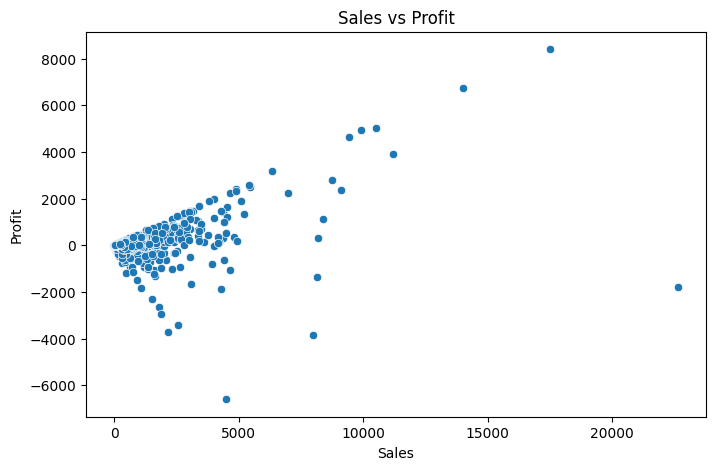

In [113]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

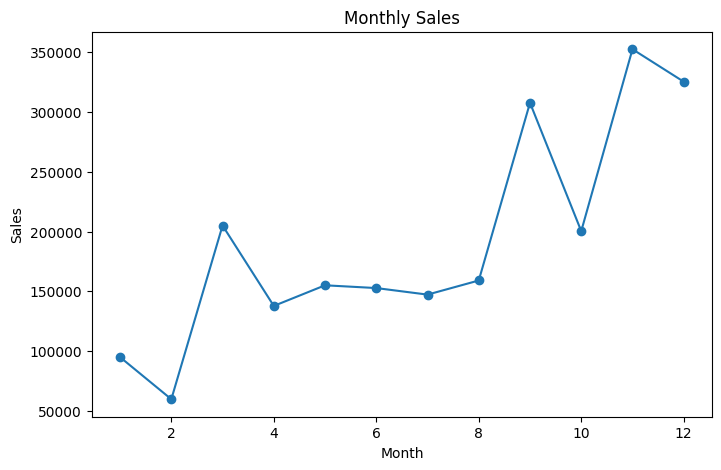

In [114]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
monthly = df.groupby(df['Order Date'].dt.month)['Sales'].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [115]:
model = LinearRegression()

In [116]:
print(X.dtypes)

Segment            int64
City               int64
State              int64
Postal Code        int64
Category           int64
Sub-Category       int64
Sales            float64
Quantity           int64
Discount         float64
Profit_Margin    float64
Is_Loss            int64
High_Discount      int64
Shipping_Days      int64
Order_Year         int32
Order_Month        int32
Order_Day          int32
dtype: object


In [117]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ----------------------------
# Encode Object Columns
# ----------------------------
le = LabelEncoder()

categorical_cols = [
    'Segment',
    'City',
    'State',
    'Category',
    'Sub-Category'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])
    else:
        print(f"Warning: Column '{col}' not found in DataFrame for encoding.")

# ----------------------------
# Check Data Types
# ----------------------------
print(df.dtypes)

Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Segment                   int64
City                      int64
State                     int64
Postal Code               int64
Category                  int64
Sub-Category              int64
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Profit_Margin           float64
Is_Loss                   int64
High_Discount             int64
Shipping_Days             int64
dtype: object


In [118]:
if 'Order Date' in df.columns and 'Ship Date' in df.columns:
    # Convert dates to useful numeric features
    df['Order_Year'] = df['Order Date'].dt.year
    df['Order_Month'] = df['Order Date'].dt.month
    df['Order_Day'] = df['Order Date'].dt.day
    df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

    # Drop the original date columns
    df.drop(['Order Date', 'Ship Date'], axis=1, inplace=True)
else:
    print("Warning: 'Order Date' or 'Ship Date' columns not found. Assuming date features were already created and original columns dropped.")

In [119]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [120]:
X = pd.get_dummies(X, drop_first=True)

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [122]:
# Predict the test data
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[115.15034745  34.10979904   1.28969252 ...   4.31692276  93.23115777
 -54.62686273]


In [123]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

R² Score : -0.6986503023426125
MAE      : 68.13372372552568
MSE      : 82359.27353714367
RMSE     : 286.98305444249434


In [124]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(results.head(10))

    Actual   Predicted
0  21.1428  115.150347
1  11.4600   34.109799
2  17.1580    1.289693
3 -15.1470  -64.739318
4  -6.4233  -69.430883
5   8.6744   39.071020
6 -73.7061  -41.790666
7   8.6900   50.769565
8 -15.0800 -105.783147
9  17.9080  -20.553674


In [125]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [132]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Scale + Lasso Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=50000))
])

# Hyperparameter tuning
param_grid = {
    'lasso__alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
print("Best Alpha :", grid.best_params_['lasso__alpha'])
print("R2 Score   :", r2_score(y_test, y_pred))
print("MAE        :", mean_absolute_error(y_test, y_pred))
print("MSE        :", mean_squared_error(y_test, y_pred))
print("RMSE       :", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Alpha : 1
R2 Score   : -0.6823510808744526
MAE        : 66.73388369445654
MSE        : 81569.00373441419
RMSE       : 285.6028776718018


In [145]:
# Example new record (same order of columns as X)

new_data = pd.DataFrame({
    'Segment': [1],
    'City': [15],
    'State': [4],
    'Postal Code': [600001],
    'Category': [2],
    'Sub-Category': [5],
    'Sales': [3000.0],  # Added a sample Sales value
    'Quantity': [10],
    'Discount': [0.10],
    'Profit_Margin': [18.5],
    'Is_Loss': [0],
    'High_Discount': [0],
    'Shipping_Days': [4],
    'Order_Year': [2018],
    'Order_Month': [6],
    'Order_Day': [15]
    # Removed Ship_Year, Ship_Month, Ship_Day as they were not in training data
})

# Predict Profit
prediction = best_model.predict(new_data)

print("Predicted Profit: ₹", round(prediction[0],2))

Predicted Profit: ₹ -19156.66


In [147]:
# Take a real sample
new_data = X_test.iloc[[0]].copy()

# Increase Sales
new_data['Sales'] = 3000

prediction = best_model.predict(new_data)

print("Predicted Profit:", round(prediction[0], 2))

Predicted Profit: 745.65


In [146]:
print(new_data.columns.tolist())
print(X_train.columns.tolist())


['Segment', 'City', 'State', 'Postal Code', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit_Margin', 'Is_Loss', 'High_Discount', 'Shipping_Days', 'Order_Year', 'Order_Month', 'Order_Day']
['Segment', 'City', 'State', 'Postal Code', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit_Margin', 'Is_Loss', 'High_Discount', 'Shipping_Days', 'Order_Year', 'Order_Month', 'Order_Day']


In [141]:
test_row = X_test.iloc[[0]]
actual = y_test.iloc[0]

prediction = best_model.predict(test_row)

print("Actual Sales    :", actual)
print("Predicted Sales :", prediction[0])

Actual Sales    : 21.1428
Predicted Sales : 108.25150688768845


In [133]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.23012239139770274


In [134]:
!pip install xgboost

In [135]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [136]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [137]:
y_pred = xgb.predict(X_test)

In [138]:
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.4533409350169041
MAE      : 13.310573086926118
MSE      : 26504.833515415998
RMSE     : 162.80305130867788
